# Ejercicio 5 - Incorporacion de los datos de 2024

Este notebook grafica los resultados de las consultas de validacion del Ejercicio 5.

**Flujo:** primero se ejecutan las consultas con `python scripts/run_sql.py ejercicio5` y la comprobacion de compatibilidad con `python scripts/compatibilidad.py`; este notebook lee los CSV que generan (pocas filas) y, si falta alguno, ejecuta la consulta en DuckDB sobre las vistas, que ahora leen 2024 y 2026 juntos.

Documentacion e interpretacion: `docs/ejercicio5_incorporacion.md`. Figuras en `docs/figuras/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # notebooks/ -> scripts/
from lab import conectar, ejecutar_sql, RAIZ_REPO

import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DIR_FIG = RAIZ_REPO / "docs" / "figuras"
DIR_FIG.mkdir(parents=True, exist_ok=True)
# Dos series por grafica: posiciones 1 y 2 de una paleta categorica validada
# (contraste >= 3:1 sobre blanco y separables con daltonismo).
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, REJILLA = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2,
    "ytick.color": TINTA_2, "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "lines.linewidth": 2, "lines.markersize": 6,
    "legend.frameon": False,
})

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(DIR_FIG / f"{nombre}.png", bbox_inches="tight")
    plt.show()

DIR_RES = RAIZ_REPO / "docs" / "resultados" / "ejercicio5"
con = None

def cargar(archivo):
    """Lee el CSV de scripts/run_sql.py; si no existe, ejecuta la consulta."""
    global con
    csv = DIR_RES / (Path(archivo).stem + ".csv")
    if csv.exists():
        print(f"[{Path(archivo).stem}] leido de {csv.relative_to(RAIZ_REPO)}")
        return pd.read_csv(csv)
    con = con or conectar()
    meta, df, seg = ejecutar_sql(con, archivo)
    print(f"[{meta.get('id')}] {meta.get('titulo', '')} ({seg:.1f} s)")
    return df

## 5.1 - 5.5 Archivos incorporados y registros por anio

Los archivos de 2024 quedan junto a los de 2026 (5.1) y la vista unificada contiene exactamente las filas que indican los metadatos de cada archivo (5.2).

In [2]:
cargar("sql/ejercicio5/5_01_archivos_por_anio.sql")

[5_01_archivos_por_anio] leido de docs/resultados/ejercicio5/5_01_archivos_por_anio.csv


,tipo,anio,archivos,primer_mes,ultimo_mes,huecos,en_carpeta_incorrecta,meses
0,yellow,2024,12,1,12,0,0,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12"
1,yellow,2026,8,1,8,0,0,"01, 02, 03, 04, 05, 06, 07, 08"
2,green,2024,12,1,12,0,0,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12"
3,green,2026,8,1,8,0,0,"01, 02, 03, 04, 05, 06, 07, 08"


In [3]:
cargar("sql/ejercicio5/5_02_registros_metadatos_vs_vista.sql")

[5_02_registros_metadatos_vs_vista] leido de docs/resultados/ejercicio5/5_02_registros_metadatos_vs_vista.csv


,taxi,anio,archivos,registros_metadatos,registros_vista,diferencia
0,yellow,2024,12,41169720.0,41169720,0.0
1,yellow,2026,8,29703355.0,29703355,0.0
2,green,2024,12,660218.0,660218,0.0
3,green,2026,8,337114.0,337114,0.0


## 5.6 Consulta conjunta: viajes por dia en cada mes, 2024 frente a 2026

Una sola consulta (`5_05`) sobre `viajes_validos` devuelve ambos anios. Cada tipo de taxi va en su propio panel porque su escala es unas 90 veces distinta (un eje por grafica).

[5_05_viajes_por_mes_y_anio] leido de docs/resultados/ejercicio5/5_05_viajes_por_mes_y_anio.csv


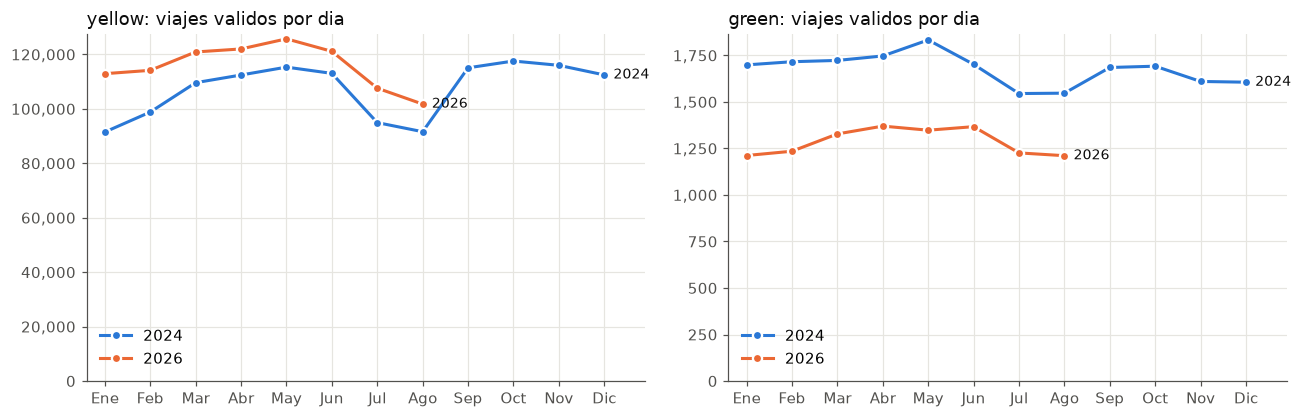

taxi   green            yellow          
anio    2024    2026      2024      2026
mes                                     
1     1699.0  1212.0   91491.0  112926.0
2     1716.0  1235.0   98826.0  114156.0
3     1723.0  1328.0  109618.0  120908.0
4     1747.0  1370.0  112440.0  122016.0
5     1833.0  1348.0  115337.0  125733.0
6     1702.0  1367.0  113036.0  121130.0
7     1545.0  1226.0   94950.0  107603.0
8     1547.0  1211.0   91604.0  101757.0
9     1685.0     NaN  115079.0       NaN
10    1692.0     NaN  117576.0       NaN
11    1610.0     NaN  115995.0       NaN
12    1606.0     NaN  112471.0       NaN

In [4]:
m = cargar("sql/ejercicio5/5_05_viajes_por_mes_y_anio.sql")
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
COLOR_ANIO = {2024: AZUL, 2026: NARANJA}

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.9))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = m[m.taxi == taxi]
    for anio, color in COLOR_ANIO.items():
        s = d[d.anio == anio].sort_values("mes")
        if s.empty:
            continue
        eje.plot(s.mes, s.viajes_por_dia, marker="o", color=color, label=str(anio),
                 markeredgecolor="white", markeredgewidth=1.5)
        ultimo = s.iloc[-1]
        eje.annotate(str(anio), (ultimo.mes, ultimo.viajes_por_dia), xytext=(6, 0),
                     textcoords="offset points", va="center", color=TINTA, fontsize=9)
    eje.set_xticks(range(1, 13), MESES)
    eje.set_xlim(0.6, 12.9)
    eje.set_ylim(bottom=0)
    eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    eje.set_title(f"{taxi}: viajes validos por dia", color=TINTA, loc="left")
    eje.legend(loc="lower left")
guardar(fig, "e5_viajes_por_dia_2024_2026")
m.pivot_table(index="mes", columns=["taxi", "anio"], values="viajes_por_dia")

## Comparacion en los mismos meses (enero a agosto)

In [5]:
cargar("sql/ejercicio5/5_06_comparacion_mismo_periodo.sql").set_index(["taxi", "anio"]).T

[5_06_comparacion_mismo_periodo] leido de docs/resultados/ejercicio5/5_06_comparacion_mismo_periodo.csv


taxi                           yellow                             green                 
anio                             2024             2026             2024             2026
meses                 1,2,3,4,5,6,7,8  1,2,3,4,5,6,7,8  1,2,3,4,5,6,7,8  1,2,3,4,5,6,7,8
viajes_validos               25223199         28127474           411994           312777
viajes_por_dia               103374.0         115751.0           1689.0           1287.0
distancia_mediana_mi              1.8             1.94             1.96             2.13
duracion_mediana_min             12.7             14.1             11.9             13.2
total_mediano_usd               20.96             23.6            19.11            20.51
total_prom_usd                  28.36            30.26            23.76            25.37
pct_tarjeta                      75.9             65.3             70.6             76.8
pct_efectivo                     13.8              9.0             29.0             22.8
pct_flex_o_sin_dato               9.1             25.0              4.1             13.6
pct_aeropuerto                  10.28             9.74             0.28             0.29
pct_cargo_cbd                     0.0             72.4              0.0              8.5

## Columnas que cambian entre anios y reglas de calidad

In [6]:
cargar("sql/ejercicio5/5_07_columnas_por_anio.sql")

[5_07_columnas_por_anio] leido de docs/resultados/ejercicio5/5_07_columnas_por_anio.csv


,taxi,anio,registros,pct_cbd_no_nulo,pct_cbd_mayor_0,pct_request_source_no_nulo,pct_airport_fee_no_nulo,pct_congestion_mayor_0,pct_pago_0,pct_pago_nulo,pct_pasajeros_nulo
0,yellow,2024,41169720,0.0,0.00,0.00,90.06,81.62,9.94,0.00,9.94
1,yellow,2026,29703355,100.0,71.76,9.77,74.02,66.07,25.98,0.00,25.98
2,green,2024,660218,0.0,0.00,0.00,0.00,28.54,0.00,3.68,3.68
3,green,2026,337114,100.0,8.32,5.70,0.00,27.48,0.00,14.47,14.47


In [7]:
cargar("sql/ejercicio5/5_08_calidad_por_anio.sql")

[5_08_calidad_por_anio] leido de docs/resultados/ejercicio5/5_08_calidad_por_anio.csv


,taxi,anio,registros,pct_fuera_periodo,pct_duracion,pct_distancia,pct_velocidad,pct_monto,pct_pasajeros,pct_excluido
0,yellow,2024,41169720,0.001,0.086,1.890,0.032,1.818,0.975,4.57
1,yellow,2026,29703355,0.000,1.276,3.210,0.027,0.607,0.308,5.31
2,green,2024,660218,0.025,0.498,5.272,0.325,0.404,1.029,7.14
3,green,2026,337114,0.029,0.397,3.644,0.344,1.838,1.343,7.22


## 5.7 Compatibilidad de las consultas de los Ejercicios 3 y 4

Cada etapa ejecuta las 29 consultas sin modificarlas sobre todo lo descargado en ese momento (`scripts/compatibilidad.py`).

In [8]:
etapas = {r.stem.removeprefix("compatibilidad_"): pd.read_csv(r)
          for r in sorted(DIR_RES.glob("compatibilidad_*.csv"))}
resumen = pd.concat({k: v.set_index(["carpeta", "consulta"])[["estado", "filas", "segundos", "vs_documentado"]]
                     for k, v in etapas.items()}, axis=1)
print({k: f"{(v.estado == 'ok').sum()}/{len(v)} sin error, {v.segundos.sum():.0f} s" for k, v in etapas.items()})
resumen

{'2024_2026': '29/29 sin error, 540 s', '2026': '29/29 sin error, 198 s'}


2024_2026                                 2026                              
                                                  estado filas segundos vs_documentado estado filas segundos vs_documentado
carpeta    consulta                                                                                                        
ejercicio3 3_01_cantidad_archivos                     ok     4    0.117       distinto     ok     2    0.036          igual
           3_02_registros_por_archivo                 ok    40    0.163       distinto     ok    16    0.059          igual
           3_03_registros_totales                     ok     3    0.442       distinto     ok     3    0.235          igual
           3_04_columnas_yellow                       ok    21    0.062          igual     ok    21    0.037          igual
           3_05_columnas_green                        ok    22    0.076          igual     ok    22    0.048          igual
           3_06_comparacion_columnas                  ok    25    0.109          igual     ok    25    0.071          igual
           3_07_tipos_por_archivo                     ok    43    0.130       distinto     ok    43    0.176          igual
           3_08_muestra_yellow                        ok    10    9.157       distinto     ok    10    6.079          igual
           3_09_muestra_green                         ok    10    0.484       distinto     ok    10    0.201          igual
           3_10_resumen_yellow                        ok    21  128.382       distinto     ok    21   56.284       distinto
           3_11_resumen_green                         ok    22    2.627       distinto     ok    22    0.957       distinto
           3_12_reglas_calidad                        ok     2   19.387       distinto     ok     2    5.079          igual
           3_13_fechas_fuera_de_mes                   ok    30    6.714       distinto     ok    30    1.879       distinto
           3_14_codigos_categoricos                   ok    41   49.989       distinto     ok    40    5.205          igual
           3_15_consistencia_montos                   ok     2   27.938       distinto     ok     2    3.289          igual
           3_16_duplicados                            ok     2   72.889       distinto     ok     2   13.274          igual
           3_17_desglose_inconsistencia_montos        ok    28   25.032       distinto     ok    27    7.507          igual
           3_18_request_source                        ok    40    2.685       distinto     ok    16    1.087       distinto
ejercicio4 4_01_viajes_por_mes                        ok    40   20.828       distinto     ok    16   10.546          igual
           4_02_hora_dia_semana                       ok   336   14.382       distinto     ok   336    6.766          igual
           4_03_caracteristicas_viaje                 ok     8   24.800       distinto     ok     8    9.842          aprox
           4_04_resumen_por_tipo                      ok     2   17.683       distinto     ok     2   12.008          igual
           4_05_viajes_por_borough                    ok    15   14.005       distinto     ok    15    7.152          igual
           4_06_metodo_pago                           ok    11   17.534       distinto     ok    10    9.133          igual
           4_07_distribucion_propina                  ok    18   14.815       distinto     ok    18    5.993          igual
           4_08_histograma_total                      ok    62   12.777       distinto     ok    62    6.154          igual
           4_09_impacto_reglas_calidad                ok    40   12.089       distinto     ok    16    5.395          igual
           4_10_atipicos_tarifa_milla                 ok     2   32.509       distinto     ok     2   15.457       distinto
           4_11_propina_sobre_total                   ok    82   12.132       distinto     ok    82    8.175          igual